# 02 - Dimensionality Reduction

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Make sure we get outputs from a probabilitistic model each time (for reproducibility)
np.random.seed(1515)

## Too Many Features, Not Enough Independent Information

`01-clustering.ipynb` worked with two features. Real scouting data has many more - climb rate, auto score, rank, cycle time, endgame reliability, and more - but many of them move together. A team with a high auto score often also has a fast cycle time; they're not really two *independent* pieces of information, just two different measurements of roughly the same underlying trait. **Dimensionality Reduction** finds a smaller set of features that still captures most of what the original, larger set was actually telling you.

## Variance, Covariance, and the Idea Behind PCA

**Principal Component Analysis (PCA)** looks for the *directions* in the data with the most **variance** - the most spread, the most actual information - and re-expresses the data in terms of those directions instead of the original features. The tool for finding those directions is the data's **Covariance Matrix**: a matrix (recall `linear_algebra_primer/02-matrices-and-transformations.ipynb`) summarizing how every pair of features varies together.

A matrix's **Eigenvectors** are directions it only stretches or shrinks, never rotates - deliberately left out of `linear_algebra_primer` as more than "just enough," and picked up here, where they're actually needed. For a covariance matrix specifically, its eigenvectors point along the directions of maximum variance in the data, and each eigenvector's corresponding **Eigenvalue** tells you exactly how much variance lies along that direction. PCA is just this: compute the covariance matrix, find its eigenvectors, and keep only the ones with the largest eigenvalues.

## PCA, From Scratch

In [2]:
def pca(X, n_components):
    mean = X.mean(axis=0)
    centered = X - mean

    covariance_matrix = np.cov(centered, rowvar=False)
    eigenvalues, eigenvectors = np.linalg.eigh(covariance_matrix)   # ascending order

    order = np.argsort(eigenvalues)[::-1]   # sort descending - largest variance first
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]

    components = eigenvectors[:, :n_components]
    projected = centered @ components   # the actual dimensionality reduction step
    explained_variance_ratio = eigenvalues[:n_components] / eigenvalues.sum()

    return projected, components, eigenvalues, explained_variance_ratio

## A Simple Case: Two Correlated Features

In [3]:
rng = np.random.default_rng(1515)
n = 100
x = rng.normal(0, 2, n)
y = 0.8 * x + rng.normal(0, 0.5, n)   # y mostly tracks x, plus some noise
correlated_data = np.column_stack([x, y])

projected, components, eigenvalues, evr = pca(correlated_data, n_components=2)
print(f"Eigenvalues: {eigenvalues.round(3)}")
print(f"Explained variance ratio: {evr.round(3)}")

Eigenvalues: [6.461 0.146]
Explained variance ratio: [0.978 0.022]


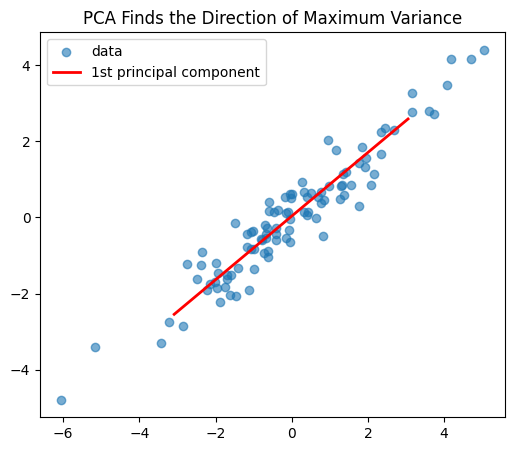

In [4]:
fig, ax = plt.subplots(figsize=(6, 5))
ax.scatter(correlated_data[:, 0], correlated_data[:, 1], alpha=0.6, label='data')
mean = correlated_data.mean(axis=0)
pc1_direction = components[:, 0]
line = np.array([mean - 4 * pc1_direction, mean + 4 * pc1_direction])
ax.plot(line[:, 0], line[:, 1], color='red', linewidth=2, label='1st principal component')
ax.set_title('PCA Finds the Direction of Maximum Variance')
ax.legend()
ax.axis('equal')
plt.show()

The first principal component should capture roughly 97-98% of the total variance by itself, and its direction should visibly line up with the diagonal spread of the data - exactly the $y \approx 0.8x$ relationship these two features were built to share. The second component (perpendicular to the first) picks up whatever's left: the noise.

## Applying This to Scouting Data

Now four features per team instead of two - `climb_rate`, `auto_score`, and two more that are each correlated with one of those: `endgame_reliability` (tracks `climb_rate`) and `cycle_speed` (tracks `auto_score`). The same three playstyles from `01-clustering.ipynb`, just described with more (partially redundant) numbers.

In [5]:
def make_group(climb_center, auto_center, n, rng):
    climb_rate = rng.normal(climb_center, 0.08, n)
    auto_score = rng.normal(auto_center, 0.4, n)
    endgame_reliability = climb_rate * 0.9 + rng.normal(0, 0.05, n)
    cycle_speed = auto_score * 0.7 + rng.normal(0, 0.3, n)
    return np.column_stack([climb_rate, auto_score, endgame_reliability, cycle_speed])

rng_teams = np.random.default_rng(1515)
n_per_group = 15
climb_specialists = make_group(0.85, 1.5, n_per_group, rng_teams)
auto_specialists = make_group(0.15, 4.5, n_per_group, rng_teams)
generalists = make_group(0.5, 2.8, n_per_group, rng_teams)

teams = np.vstack([climb_specialists, auto_specialists, generalists])
true_playstyle = np.array([0] * n_per_group + [1] * n_per_group + [2] * n_per_group)
print(f"teams shape: {teams.shape}  (4 features per team)")

# recall 01-clustering.ipynb: any distance-based method needs standardized features
teams_scaled = (teams - teams.mean(axis=0)) / teams.std(axis=0)

projected_teams, components_teams, eigenvalues_teams, evr_teams = pca(teams_scaled, n_components=2)
print(f"Eigenvalues: {eigenvalues_teams.round(3)}")
print(f"Explained variance ratio (top 2 of 4 components): {evr_teams.round(3)}, "
      f"total: {evr_teams.sum():.1%}")

teams shape: (45, 4)  (4 features per team)
Eigenvalues: [3.832 0.186 0.058 0.015]
Explained variance ratio (top 2 of 4 components): [0.937 0.046], total: 98.2%


Two components out of the original four should already capture roughly 98% of the total variance - strong evidence that these four features never really carried four independent dimensions of information to begin with, just two, measured twice each in slightly different ways.

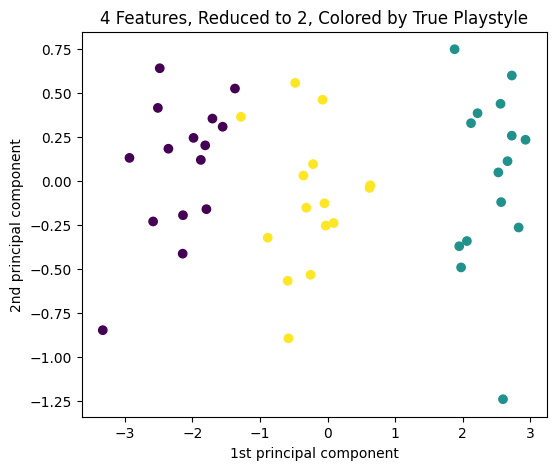

In [6]:
plt.figure(figsize=(6, 5))
plt.scatter(projected_teams[:, 0], projected_teams[:, 1], c=true_playstyle, cmap='viridis')
plt.xlabel('1st principal component')
plt.ylabel('2nd principal component')
plt.title('4 Features, Reduced to 2, Colored by True Playstyle')
plt.show()

The three playstyles should still separate cleanly in just two dimensions - `01-clustering.ipynb`'s K-Means (with K-Means++ initialization) run directly on this 2D projection recovers essentially the same groups as running it on the full 4D data, just faster and with less to plot.

## Try It Yourself

Add a 5th feature to `make_group` that's *not* correlated with anything else - pure independent noise, e.g. `rng.normal(0, 1, n)` (something meaningless, like a randomly assigned scouting-sheet ID number). Rerun PCA with `n_components=2` on the resulting 5-feature data. Does the explained variance ratio for the top 2 components go up, down, or stay about the same compared to the 4-feature version - and does the answer make sense given that the new feature carries no real shared structure with anything else?

In [7]:
# TODO: add a 5th, uncorrelated random feature to make_group, rerun PCA with
# n_components=2, and compare the new explained variance ratio to the 4-feature version


## Resources

- Pearson, K. (1901). "On Lines and Planes of Closest Fit to Systems of Points in Space." *Philosophical Magazine*. The original paper behind PCA (paper).
- [3Blue1Brown: Eigenvectors and Eigenvalues](https://www.3blue1brown.com/lessons/eigenvalues-and-eigenvectors) - an intuitive visual explanation of what this notebook used numerically (video).
- [scikit-learn: `PCA` documentation](https://scikit-learn.org/stable/modules/generated/sklearn.decomposition.PCA.html) - the real, production implementation (reference).